In [4]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [5]:
'''import pathlib
import tensorflow as tf

DATASET_ROOT = pathlib.Path("data")
DATASET_PATH = DATASET_ROOT / "speech_commands"

DATASET_ROOT.mkdir(exist_ok=True)

if not DATASET_PATH.exists():
    archive_path = tf.keras.utils.get_file(
        "speech_commands_v0.02.tar.gz",
        origin="https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz",
        cache_dir=str(DATASET_ROOT),
        cache_subdir="downloads"
    )

    print("Downloaded:", archive_path)'''

'import pathlib\nimport tensorflow as tf\n\nDATASET_ROOT = pathlib.Path("data")\nDATASET_PATH = DATASET_ROOT / "speech_commands"\n\nDATASET_ROOT.mkdir(exist_ok=True)\n\nif not DATASET_PATH.exists():\n    archive_path = tf.keras.utils.get_file(\n        "speech_commands_v0.02.tar.gz",\n        origin="https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz",\n        cache_dir=str(DATASET_ROOT),\n        cache_subdir="downloads"\n    )\n\n    print("Downloaded:", archive_path)'

In [6]:
import os

print(os.getcwd())

/home/deepak/projects/keyword-recognition/notebooks


In [7]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
data_dir = PROJECT_ROOT / "data" / "speech_commands"

print(data_dir)

/home/deepak/projects/keyword-recognition/data/speech_commands


In [8]:
TARGET_COMMANDS = [
    "yes", "no", "up", "down",
    "left", "right", "on", "off"
]

commands = np.array([
    command for command in tf.io.gfile.listdir(str(data_dir))
    if command in TARGET_COMMANDS
])

commands = np.sort(commands)

print("Commands:", commands)
print("Number of classes:", len(commands))

Commands: ['down' 'left' 'no' 'off' 'on' 'right' 'up' 'yes']
Number of classes: 8


In [9]:
from pathlib import Path

for command in commands:
    command_dir = data_dir / command
    wav_files = list(command_dir.glob("*.wav"))
    
    print(f"{command:>5}: {len(wav_files)} files")

 down: 3917 files
 left: 3801 files
   no: 3941 files
  off: 3745 files
   on: 3845 files
right: 3778 files
   up: 3723 files
  yes: 4044 files


In [10]:
sample_command = "yes"

sample_files = list((data_dir / sample_command).glob("*.wav"))

sample_file = sample_files[0]

print("Sample file:", sample_file)

Sample file: /home/deepak/projects/keyword-recognition/data/speech_commands/yes/ab46af55_nohash_2.wav


In [11]:
audio, sample_rate = tf.audio.decode_wav(
    tf.io.read_file(str(sample_file))
)

print("Audio shape:", audio.shape)
print("Sample rate:", sample_rate.numpy())

Audio shape: (16000, 1)
Sample rate: 16000


W0000 00:00:1789362134.133512   34175 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

example_audio = []
example_labels = []

for label_index, command in enumerate(commands):
    wav_files = list((data_dir / command).glob("*.wav"))
    
    # Take the first file from each class
    wav_file = wav_files[0]
    
    audio_binary = tf.io.read_file(str(wav_file))
    audio, sample_rate = tf.audio.decode_wav(
        audio_binary,
        desired_channels=1
    )
    
    example_audio.append(tf.squeeze(audio))
    example_labels.append(label_index)

example_audio = np.array(example_audio)
example_labels = np.array(example_labels)

label_names = commands

print("Audio shape:", example_audio.shape)
print("Labels:", example_labels)
print("Sample rate:", sample_rate.numpy())

Audio shape: (8, 16000)
Labels: [0 1 2 3 4 5 6 7]
Sample rate: 16000


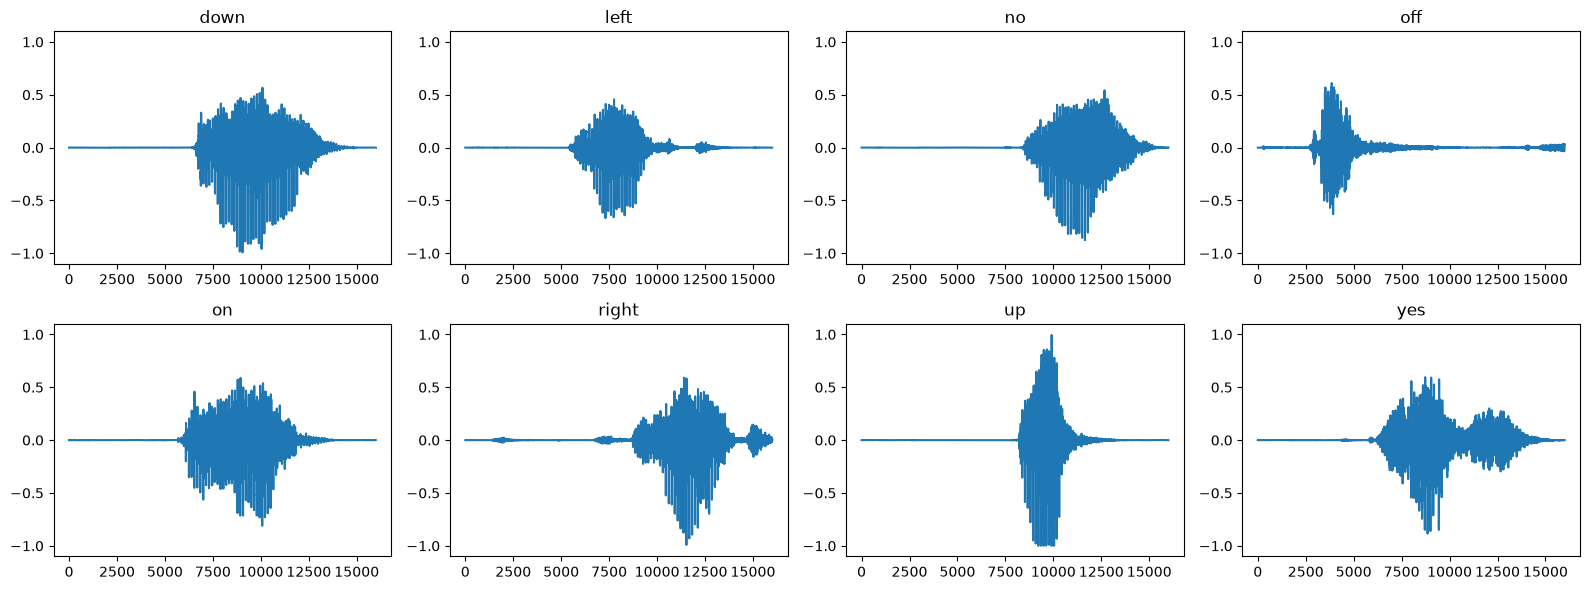

In [13]:
plt.figure(figsize=(16, 6))

rows = 2
cols = 4

for i in range(8):
    plt.subplot(rows, cols, i + 1)
    plt.plot(example_audio[i])
    plt.title(label_names[example_labels[i]])
    plt.ylim([-1.1, 1.1])

plt.tight_layout()
plt.show()

## Convert waveforms into spectograms

In [14]:
def get_spectrogram(waveform):
    
    waveform = waveform[:16000]

    zero_padding = tf.zeros(
        [16000] - tf.shape(waveform),
        dtype=tf.float32
    )

    waveform = tf.cast(waveform, tf.float32)
    equal_length = tf.concat([waveform, zero_padding], axis=0)

    
    spectrogram = tf.signal.stft(
        equal_length,
        frame_length=255,
        frame_step=128
    )
    spectrogram = tf.abs(spectrogram)

    return spectrogram

In [15]:
from IPython import display

for i in range(3):
    label = label_names[example_labels[i]]
    waveform = example_audio[i]
    spectrogram = get_spectrogram(waveform)

    print("Label:", label)
    print("Waveform shape:", waveform.shape)
    print("Spectrogram shape:", spectrogram.shape)
    print("Audio playback:")

    display.display(
        display.Audio(waveform, rate=16000)
    )

Label: down
Waveform shape: (16000,)
Spectrogram shape: (124, 129)
Audio playback:


Label: left
Waveform shape: (16000,)
Spectrogram shape: (124, 129)
Audio playback:


Label: no
Waveform shape: (16000,)
Spectrogram shape: (124, 129)
Audio playback:


In [16]:
def plot_spectrogram(spectrogram, ax):
    if len(spectrogram.shape) > 2:
        assert len(spectrogram.shape) == 3
        spectrogram = np.squeeze(spectrogram, axis=-1)

    # Transpose so:
    # x-axis = time
    # y-axis = frequency
    log_spec = np.log(
        spectrogram.T + np.finfo(float).eps
    )

    height = log_spec.shape[0]
    width = log_spec.shape[1]

    X = np.linspace(
        0,
        np.size(spectrogram),
        num=width,
        dtype=int
    )

    Y = range(height)

    ax.pcolormesh(X, Y, log_spec)

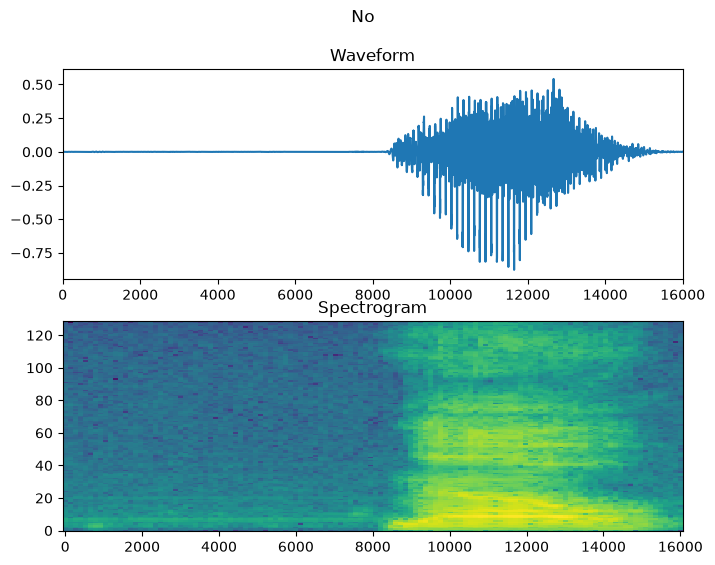

In [18]:
fig, axes = plt.subplots(2, figsize=(8, 6))

# Waveform
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform)
axes[0].set_title("Waveform")
axes[0].set_xlim([0, 16000])

# Spectrogram
plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title("Spectrogram")

plt.suptitle(label.title())
plt.show()

## Train Val Test split

In [19]:
TARGET_COMMANDS = [
    "yes", "no", "up", "down",
    "left", "right", "on", "off"
]


label_names = np.array(sorted(TARGET_COMMANDS))

label_to_index = {
    label: index
    for index, label in enumerate(label_names)
}

print("Classes:", label_names)
print("Label mapping:", label_to_index)

Classes: ['down' 'left' 'no' 'off' 'on' 'right' 'up' 'yes']
Label mapping: {np.str_('down'): 0, np.str_('left'): 1, np.str_('no'): 2, np.str_('off'): 3, np.str_('on'): 4, np.str_('right'): 5, np.str_('up'): 6, np.str_('yes'): 7}


In [20]:
validation_file = data_dir / "validation_list.txt"
testing_file = data_dir / "testing_list.txt"

def read_split_file(file_path):
    with open(file_path, "r") as f:
        return [
            line.strip()
            for line in f
            if line.strip()
        ]

validation_paths = read_split_file(validation_file)
testing_paths = read_split_file(testing_file)

print("Validation files:", len(validation_paths))
print("Testing files:", len(testing_paths))

Validation files: 9981
Testing files: 11005


In [21]:
def is_target_command(path):
    command = path.split("/")[0]
    return command in label_to_index

validation_paths = [
    path for path in validation_paths
    if is_target_command(path)
]

testing_paths = [
    path for path in testing_paths
    if is_target_command(path)
]

print("Target validation files:", len(validation_paths))
print("Target testing files:", len(testing_paths))

Target validation files: 2981
Target testing files: 3261


In [22]:
all_paths = []

for command in label_names:
    command_dir = data_dir / command

    for wav_file in command_dir.glob("*.wav"):
        relative_path = f"{command}/{wav_file.name}"
        all_paths.append(relative_path)

validation_set = set(validation_paths)
testing_set = set(testing_paths)

training_paths = [
    path for path in all_paths
    if path not in validation_set
    and path not in testing_set
]

print("Training files:", len(training_paths))
print("Validation files:", len(validation_paths))
print("Testing files:", len(testing_paths))
print("Total:", len(training_paths) + len(validation_paths) + len(testing_paths))

Training files: 24552
Validation files: 2981
Testing files: 3261
Total: 30794


In [30]:
def load_audio(path, label):
    audio_binary = tf.io.read_file(path)

    audio, sample_rate = tf.audio.decode_wav(
        audio_binary,
        desired_channels=1
    )

    # Remove the channel dimension
    audio = tf.squeeze(audio, axis=-1)

    return audio, label

In [31]:
def make_audio_ds(paths):
    full_paths = [
        str(data_dir / path)
        for path in paths
    ]

    labels = [
        label_to_index[path.split("/")[0]]
        for path in paths
    ]

    ds = tf.data.Dataset.from_tensor_slices(
        (full_paths, labels)
    )

    ds = ds.map(
        load_audio,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds

In [28]:
train_ds = make_audio_ds(training_paths)
val_ds = make_audio_ds(validation_paths)
test_ds = make_audio_ds(testing_paths)

In [32]:
def make_spec_ds(ds):
    return ds.map(
        map_func=lambda audio, label: (
            get_spectrogram(audio),
            label
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

In [34]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

## Plot spectrogram dataset

In [38]:
for example_spectrogram, example_spect_label in train_spectrogram_ds.take(9):

    print(
        "Spectrogram shape:",
        example_spectrogram.shape,
        "Label:",
        label_names[example_spect_label.numpy()]
    )

Spectrogram shape: (124, 129) Label: down
Spectrogram shape: (124, 129) Label: down
Spectrogram shape: (124, 129) Label: down
Spectrogram shape: (124, 129) Label: down
Spectrogram shape: (124, 129) Label: down
Spectrogram shape: (124, 129) Label: down
Spectrogram shape: (124, 129) Label: down
Spectrogram shape: (124, 129) Label: down
Spectrogram shape: (124, 129) Label: down


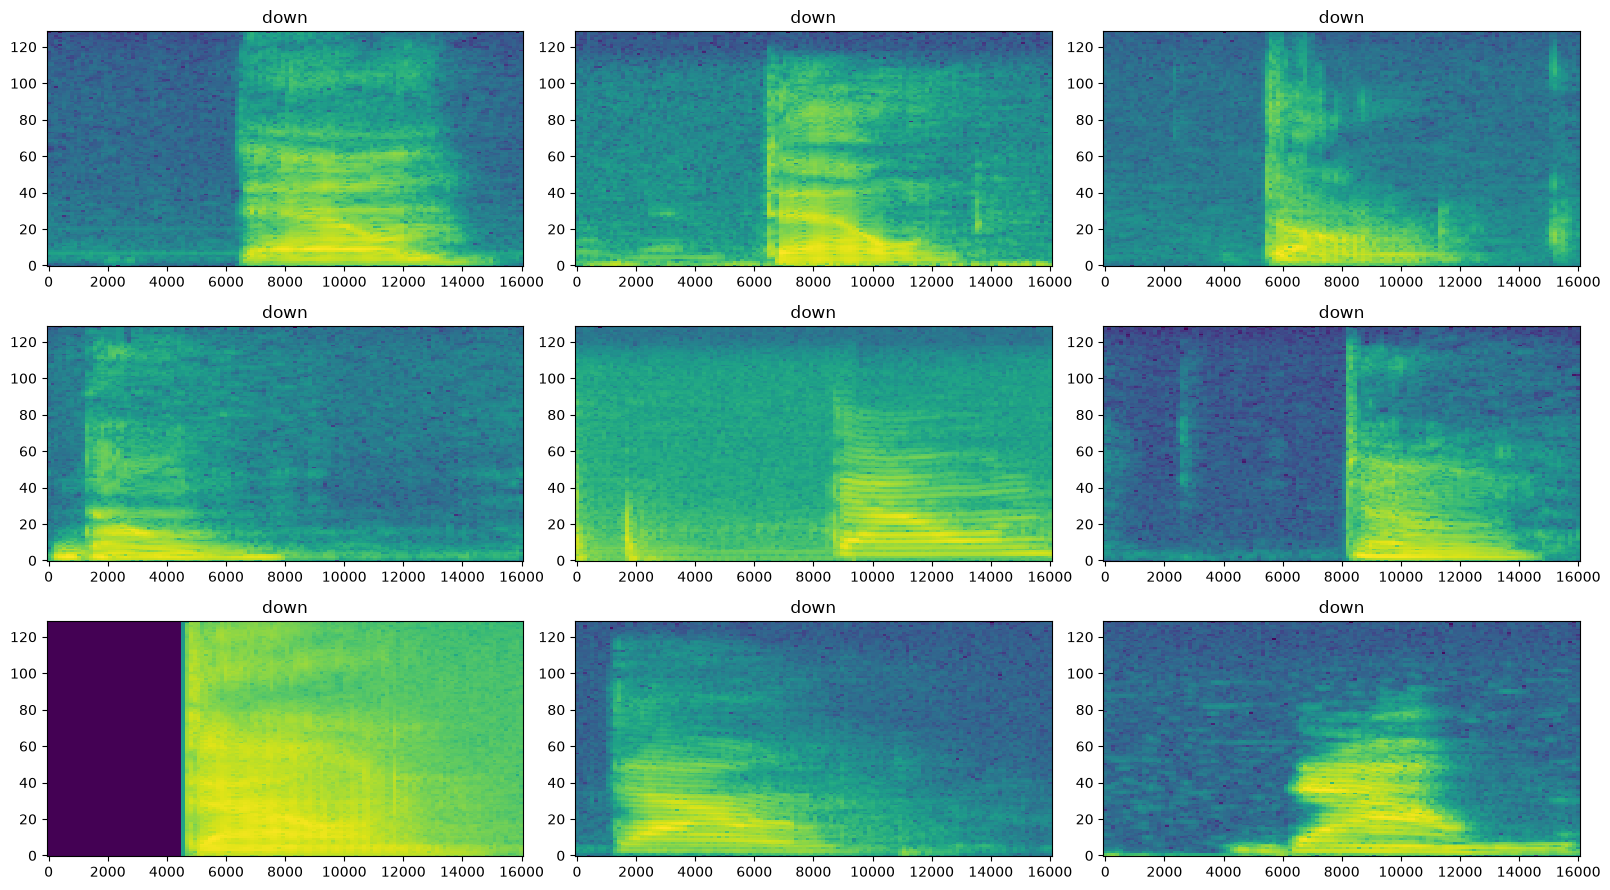

In [39]:
rows = 3
cols = 3

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, 9)
)

for i, (spectrogram, label) in enumerate(
    train_spectrogram_ds.take(9)
):
    r = i // cols
    c = i % cols

    ax = axes[r][c]

    plot_spectrogram(
        spectrogram.numpy(),
        ax
    )

    ax.set_title(
        label_names[label.numpy()]
    )

plt.tight_layout()
plt.show()